# Phase 1: Create a realistic database

### Step 1: Creating a database & tables

In [1]:
import sqlite3
import random
from datetime import datetime, timedelta

conn = sqlite3.connect("scaled_performance.db")
cursor = conn.cursor()

# Drop tables if re-running
cursor.execute("DROP TABLE IF EXISTS customers")
cursor.execute("DROP TABLE IF EXISTS products")
cursor.execute("DROP TABLE IF EXISTS orders")

# Customers
cursor.execute("""
CREATE TABLE customers (
    customer_id INTEGER PRIMARY KEY,
    name TEXT,
    city TEXT,
    age INTEGER,
    signup_date TEXT
)
""")

# Products
cursor.execute("""
CREATE TABLE products (
    product_id INTEGER PRIMARY KEY,
    category TEXT,
    price REAL
)
""")

# Orders
cursor.execute("""
CREATE TABLE orders (
    order_id INTEGER PRIMARY KEY,
    customer_id INTEGER,
    product_id INTEGER,
    quantity INTEGER,
    order_date TEXT,
    FOREIGN KEY(customer_id) REFERENCES customers(customer_id),
    FOREIGN KEY(product_id) REFERENCES products(product_id)
)
""")


### Step 2: Populating the DB with synthetic data (realistic size)

In [2]:
# Insert customers (25,000)
cities = ["Delhi","Mumbai","Bangalore","Chennai","Hyderabad","Kolkata","Dehradun","Pune"]
start_date = datetime(2020,1,1)

for i in range(1, 25001):
    signup = start_date + timedelta(days=random.randint(0,1000))
    cursor.execute(
        "INSERT INTO customers VALUES (?, ?, ?, ?, ?)",
        (i,
         f"Customer_{i}",
         random.choice(cities),
         random.randint(18,70),
         signup.strftime("%Y-%m-%d"))
    )

# Insert products (1000)
categories = ["Electronics","Clothing","Home","Sports","Books","Moto","Edibles","Jewellry"]

for i in range(1, 1001):
    cursor.execute(
        "INSERT INTO products VALUES (?, ?, ?)",
        (i,
         random.choice(categories),
         random.uniform(100,5000))
    )

# Insert orders (150,000)
for i in range(1, 150001):
    order_date = start_date + timedelta(days=random.randint(0,1500))
    cursor.execute(
        "INSERT INTO orders VALUES (?, ?, ?, ?, ?)",
        (i,
         random.randint(1,10000),
         random.randint(1,500),
         random.randint(1,10),
         order_date.strftime("%Y-%m-%d"))
    )

conn.commit()


### Lets check if the data is feeded properly:

In [3]:
cursor.execute("SELECT COUNT(*) FROM orders")
print(cursor.fetchone())



(150000,)


# Phase 2 — Automated Query Logging

#### Here we will: Automatically run hundreds of SQL queries

Measure:
- execution time
- rows processed
- query complexity
Store this as a performance dataset which will becomes our ML training data.

### Creating different types of queries automatically

We’ll generate:

*  simple queries (fast)
*  join queries (medium)
*  heavy aggregation queries (slow)

In [4]:
import time
from datetime import datetime, timedelta
import random

query_logs = []

QUERY_VOLUME = 8000


for _ in range(QUERY_VOLUME):

    query_type = random.choice([
        "lookup",
        "city_filter",
        "date_range",
        "join_query",
        "aggregation",
        "heavy_join"
    ])

    if query_type == "lookup":
        customer_id = random.randint(1,10000)
        query = f"""
        SELECT * FROM customers
        WHERE customer_id = {customer_id}
        """
        joins = 0
        aggregation = 0
        filters = 1

    elif query_type == "city_filter":
        city = random.choice(cities)
        age_threshold = random.randint(20,60)
        query = f"""
        SELECT * FROM customers
        WHERE city = '{city}'
        AND age > {age_threshold}
        """
        joins = 0
        aggregation = 0
        filters = 2

    elif query_type == "date_range":
        start_year = random.randint(2020,2023)
        duration_days = random.randint(30,600)

        start_date = datetime(start_year,1,1)
        end_date = start_date + timedelta(days=duration_days)

        query = f"""
        SELECT * FROM orders
        WHERE order_date BETWEEN '{start_date.strftime('%Y-%m-%d')}'
        AND '{end_date.strftime('%Y-%m-%d')}'
        """
        joins = 0
        aggregation = 0
        filters = 1

    elif query_type == "join_query":
        age_threshold = random.randint(25,65)
        query = f"""
        SELECT c.city, o.quantity
        FROM customers c
        JOIN orders o ON c.customer_id = o.customer_id
        WHERE c.age > {age_threshold}
        """
        joins = 1
        aggregation = 0
        filters = 1

    elif query_type == "aggregation":
        query = f"""
        SELECT city, COUNT(*)
        FROM customers
        GROUP BY city
        HAVING COUNT(*) > {random.randint(1000,3000)}
        """
        joins = 0
        aggregation = 1
        filters = 1

    else:  # heavy_join
        category = random.choice(categories)
        query = f"""
        SELECT p.category, SUM(o.quantity)
        FROM orders o
        JOIN products p ON o.product_id = p.product_id
        JOIN customers c ON o.customer_id = c.customer_id
        WHERE p.category = '{category}'
        GROUP BY p.category
        """
        joins = 2
        aggregation = 1
        filters = 1

    start = time.time()
    cursor.execute(query)
    rows = cursor.fetchall()
    end = time.time()

    execution_time = end - start
    rows_returned = len(rows)

    query_logs.append([
        execution_time,
        rows_returned,
        joins,
        aggregation,
        filters,
        query_type,
        query
    ])


### Step 2.3: Now we will convert logs into a dataset:

In [5]:
import pandas as pd

df_real = pd.DataFrame(query_logs, columns=[
    "execution_time",
    "rows_returned",
    "join_count",
    "aggregation",
    "filter_count",
    "query_type",
    "query_text"
])

df_real["query_type"].value_counts()



,count
query_type,
lookup,1359
join_query,1358
heavy_join,1342
aggregation,1327
city_filter,1322
date_range,1292


In [6]:
df_real.describe()

,execution_time,rows_returned,join_count,aggregation,filter_count
count,8000.000000,8000.000000,8000.00000,8000.000000,8000.000000
mean,0.048998,16821.293125,0.50525,0.333625,1.165250
std,0.053101,29792.931003,0.76521,0.471537,0.371429
min,0.000019,1.000000,0.00000,0.000000,1.000000
25%,0.006528,1.000000,0.00000,0.000000,1.000000
50%,0.024630,8.000000,0.00000,0.000000,1.000000
75%,0.074102,24476.000000,1.00000,1.000000,1.000000
max,0.609834,126803.000000,2.00000,1.000000,2.000000


In [7]:
df_real.groupby("query_type")["execution_time"].describe()


,count,mean,std,min,25%,50%,75%,max
query_type,,,,,,,,
aggregation,1327.0,0.013668,0.003969,0.010531,0.010942,0.011634,0.015209,0.037471
city_filter,1322.0,0.007306,0.003038,0.003409,0.005153,0.006508,0.008738,0.030396
date_range,1292.0,0.068294,0.035216,0.020984,0.045328,0.064623,0.082007,0.609834
heavy_join,1342.0,0.069295,0.016607,0.056280,0.060198,0.062727,0.067362,0.219596
join_query,1358.0,0.133546,0.044962,0.067572,0.099816,0.128432,0.154843,0.334790
lookup,1359.0,0.001182,0.001783,0.000019,0.000123,0.000197,0.001666,0.009049


# Phase 3 — Add Performance Intelligence Features

#### I’ll be adding here:
Complexity score:
- Combine joins + aggregation + filters

Scan ratio
- rows_returned / total_rows

Execution efficiency
- execution_time / rows_returned

Query length
- len(query string)

In [8]:
# Complexity score
df_real["complexity_score"] = (
    df_real["join_count"] * 2 +
    df_real["aggregation"] * 3 +
    df_real["filter_count"]
)

# Scan ratio (normalize roughly by max rows)
max_rows = df_real["rows_returned"].max()
df_real["scan_ratio"] = df_real["rows_returned"] / max_rows

# Efficiency metric
df_real["time_per_row"] = df_real["execution_time"] / (df_real["rows_returned"] + 1)

df_real.head(10)


,execution_time,rows_returned,join_count,aggregation,filter_count,query_type,query_text,complexity_score,scan_ratio,time_per_row
0,0.076988,38966,0,0,1,date_range,\n SELECT * FROM orders\n WHERE ...,1,0.307296,0.000002
1,0.088601,47905,0,0,1,date_range,\n SELECT * FROM orders\n WHERE ...,1,0.377791,0.000002
2,0.060257,28976,0,0,1,date_range,\n SELECT * FROM orders\n WHERE ...,1,0.228512,0.000002
3,0.014270,8,0,1,1,aggregation,"\n SELECT city, COUNT(*)\n FROM ...",4,0.000063,0.001586
4,0.042476,19294,0,0,1,date_range,\n SELECT * FROM orders\n WHERE ...,1,0.152157,0.000002
5,0.069695,1,2,1,1,heavy_join,"\n SELECT p.category, SUM(o.quantity)\n...",8,0.000008,0.034848
6,0.090791,52923,0,0,1,date_range,\n SELECT * FROM orders\n WHERE ...,1,0.417364,0.000002
7,0.065941,1,2,1,1,heavy_join,"\n SELECT p.category, SUM(o.quantity)\n...",8,0.000008,0.032971
8,0.138277,96093,1,0,1,join_query,"\n SELECT c.city, o.quantity\n F...",3,0.757813,0.000001
9,0.003965,1,0,0,1,lookup,\n SELECT * FROM customers\n WHE...,1,0.000008,0.001983


### PHASE 4 — Advanced Anomaly Detection

#### Step 4.1 — Encode query type:

In [9]:
df_ml = pd.get_dummies(df_real, columns=["query_type"], drop_first=True)


#### STEP 4.2 — Build feature matrix

In [10]:
features = [
    "execution_time",
    "rows_returned",
    "join_count",
    "aggregation",
    "filter_count",
    "complexity_score",
    "scan_ratio",
    "time_per_row"
]

X = df_ml[features]


#### STEP 4.3 — Scale performance features:

In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


#### STEP 4.4 — Create baseline/train and detection/test sets:

In [12]:
split_index = int(len(X_scaled) * 0.6)

X_train = X_scaled[:split_index]
X_test = X_scaled[split_index:]

df_test = df_real.iloc[split_index:].copy()


### STEP 4.5 — Train anomaly model on baseline workload:


### We will use a model called:

#Isolation Forest

It:
- Learns what normal data looks like
- Anything that looks unusual it will flag it as anomaly

This is perfect for:
- performance spikes
- inefficient queries

In [13]:
from sklearn.ensemble import IsolationForest

model = IsolationForest(
    n_estimators=200,
    contamination=0.05,
    random_state=42
)

model.fit(X_train)


IsolationForest(contamination=0.05, n_estimators=200, random_state=42)

#### STEP 4.6 — Detect anomalies on new workload:

In [14]:
df_test["anomaly_flag"] = model.predict(X_test)

df_test["anomaly_flag"].value_counts()


,count
anomaly_flag,
1,3041
-1,159


#### STEP 4.7 — Inspect anomalous queries:

In [15]:
anomalies = df_test[df_test["anomaly_flag"] == -1]
anomalies.head(10)


,execution_time,rows_returned,join_count,aggregation,filter_count,query_type,query_text,complexity_score,scan_ratio,time_per_row,anomaly_flag
4836,0.076547,1,2,1,1,heavy_join,"\n SELECT p.category, SUM(o.quantity)\n...",8,0.000008,0.038273,-1
4965,0.225612,73098,1,0,1,join_query,"\n SELECT c.city, o.quantity\n F...",3,0.576469,0.000003,-1
4968,0.112470,1,2,1,1,heavy_join,"\n SELECT p.category, SUM(o.quantity)\n...",8,0.000008,0.056235,-1
4971,0.279898,126803,1,0,1,join_query,"\n SELECT c.city, o.quantity\n F...",3,1.000000,0.000002,-1
4972,0.106565,1,2,1,1,heavy_join,"\n SELECT p.category, SUM(o.quantity)\n...",8,0.000008,0.053282,-1
4980,0.186649,59265,0,0,1,date_range,\n SELECT * FROM orders\n WHERE ...,1,0.467379,0.000003,-1
4982,0.104636,1,2,1,1,heavy_join,"\n SELECT p.category, SUM(o.quantity)\n...",8,0.000008,0.052318,-1
4987,0.098711,1,2,1,1,heavy_join,"\n SELECT p.category, SUM(o.quantity)\n...",8,0.000008,0.049356,-1
4989,0.111103,1,2,1,1,heavy_join,"\n SELECT p.category, SUM(o.quantity)\n...",8,0.000008,0.055551,-1
4993,0.025645,8,0,1,1,aggregation,"\n SELECT city, COUNT(*)\n FROM ...",4,0.000063,0.002849,-1


### Quick observation:

#### Case 1: Heavy join returning 1 row but very slow

Example:
- heavy_join
- rows_returned = 1
- execution_time = 0.09 - 0.11
- time_per_row = very high
- complexity_score = 8

This simulates:
- Huge scan
- heavy joins
- almost no output

This is exactly a bad query plan in real life.

ML caught it.

#### Case 2: Join queries scanning massive data

Example:
- join_query
- rows_returned = 126803
- execution_time = 0.10 - 0.20
- scan_ratio = 1.0 (full table)

This is:
- poor filtering
- full scan joins

ML caught it.

#### Merging the anomaly results back into main dataset:

In [16]:
# Initialize all as normal
df_real["anomaly_flag"] = 1

# Insert detected anomalies into test portion
df_real.iloc[split_index:, df_real.columns.get_loc("anomaly_flag")] = df_test["anomaly_flag"].values


In [17]:
df_real["anomaly_flag"].value_counts()


,count
anomaly_flag,
1,7841
-1,159


### ROOT CAUSE CLASSIFICATION(Simulated_parameters):

In [18]:
def classify_root_cause(row):

    if row["time_per_row"] > 0.01 and row["rows_returned"] < 10:
        return "Heavy scan with poor selectivity"

    if row["join_count"] >= 2 and row["execution_time"] > 0.05:
        return "Complex join bottleneck"

    if row["scan_ratio"] > 0.8 and row["execution_time"] > 0.08:
        return "Full table scan"

    if row["aggregation"] == 1 and row["execution_time"] > 0.04:
        return "Expensive aggregation"

    return "General inefficiency"


anomalies = df_real[df_real["anomaly_flag"] == -1].copy()
anomalies["root_cause"] = anomalies.apply(classify_root_cause, axis=1)

anomalies["root_cause"].value_counts()



,count
root_cause,
Heavy scan with poor selectivity,89
General inefficiency,41
Full table scan,29


### PERFORMANCE IMPACT:

In [19]:
normal_avg_time = df_real[df_real["anomaly_flag"] == 1]["execution_time"].mean()

anomalies["wasted_time"] = anomalies["execution_time"] - normal_avg_time

anomalies[["execution_time","wasted_time"]].describe()


,execution_time,wasted_time
count,159.000000,159.000000
mean,0.135108,0.087856
std,0.073491,0.073491
min,0.025360,-0.021892
25%,0.097431,0.050179
50%,0.107381,0.060129
75%,0.176897,0.129645
max,0.297302,0.250050


In [20]:
anomalies["wasted_time"].sum()

np.float64(13.96912390281771)

### DRIFT DETECTION:

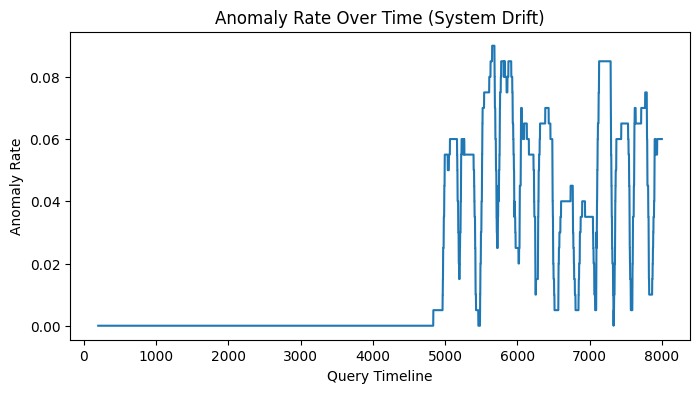

In [21]:
df_real["time_step"] = range(len(df_real))
df_real["is_anomaly"] = (df_real["anomaly_flag"] == -1).astype(int)

rolling_anomaly_rate = df_real["is_anomaly"].rolling(200).mean()

import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.plot(rolling_anomaly_rate)
plt.title("Anomaly Rate Over Time (System Drift)")
plt.xlabel("Query Timeline")
plt.ylabel("Anomaly Rate")
plt.show()


### Performance gap:

/tmp/ipython-input-170/2969021388.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


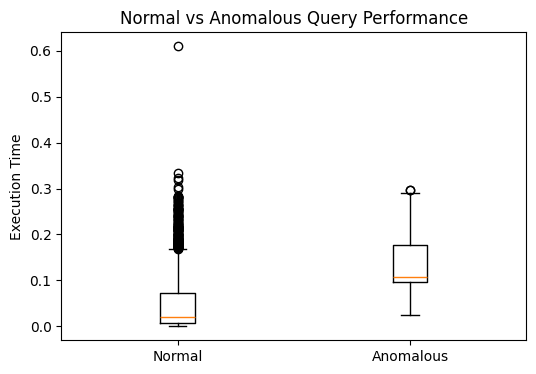

In [22]:
plt.figure(figsize=(6,4))
plt.boxplot(
    [df_real[df_real["anomaly_flag"]==1]["execution_time"],
     df_real[df_real["anomaly_flag"]==-1]["execution_time"]],
    labels=["Normal","Anomalous"]
)
plt.ylabel("Execution Time")
plt.title("Normal vs Anomalous Query Performance")
plt.show()


### Root cause distribution::

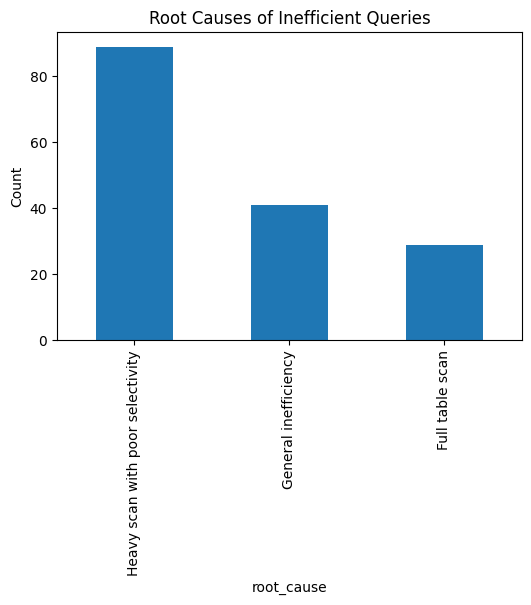

In [23]:
anomalies["root_cause"].value_counts().plot(kind="bar", figsize=(6,4))
plt.title("Root Causes of Inefficient Queries")
plt.ylabel("Count")
plt.show()


In [24]:
anomalies.head()

,execution_time,rows_returned,join_count,aggregation,filter_count,query_type,query_text,complexity_score,scan_ratio,time_per_row,anomaly_flag,root_cause,wasted_time
4836,0.076547,1,2,1,1,heavy_join,"\n SELECT p.category, SUM(o.quantity)\n...",8,0.000008,0.038273,-1,Heavy scan with poor selectivity,0.029295
4965,0.225612,73098,1,0,1,join_query,"\n SELECT c.city, o.quantity\n F...",3,0.576469,0.000003,-1,General inefficiency,0.178360
4968,0.112470,1,2,1,1,heavy_join,"\n SELECT p.category, SUM(o.quantity)\n...",8,0.000008,0.056235,-1,Heavy scan with poor selectivity,0.065217
4971,0.279898,126803,1,0,1,join_query,"\n SELECT c.city, o.quantity\n F...",3,1.000000,0.000002,-1,Full table scan,0.232646
4972,0.106565,1,2,1,1,heavy_join,"\n SELECT p.category, SUM(o.quantity)\n...",8,0.000008,0.053282,-1,Heavy scan with poor selectivity,0.059312


# Optimization logic Model:

### Step 1 — Define Optimization Actions (target labels)

| Label          | Meaning                       |
| -------------- | ----------------------------- |
| add_index      | Missing index                 |
| improve_filter | Better WHERE clauses          |
| rewrite_query  | Simplify structure            |
| reduce_joins   | Denormalize or optimize joins |
| partition_data | Time/range partition          |
| no_action      | Already acceptable            |


### Step 2 — Create training dataset from anomalies:

In [25]:
def generate_optimization_label(row):

    if row["scan_ratio"] > 0.8 and row["join_count"] >= 1:
        return "add_index"

    if row["time_per_row"] > 0.01 and row["rows_returned"] < 10:
        return "improve_filter"

    if row["complexity_score"] >= 6:
        return "rewrite_query"

    if row["join_count"] >= 2 and row["execution_time"] > 0.07:
        return "reduce_joins"

    if row["scan_ratio"] > 0.9 and row["aggregation"] == 1:
        return "partition_data"

    return "no_action"


anomalies["optimization_action"] = anomalies.apply(
    generate_optimization_label, axis=1
)

anomalies["optimization_action"].value_counts()


,count
optimization_action,
improve_filter,89
no_action,41
add_index,29


#### This creates a labeled optimization dataset

Now each anomaly has:
- performance features
- recommended fix (target)

This becomes a supervised ML problem.

### Step 3 — Prepare ML data:

In [26]:
from sklearn.preprocessing import LabelEncoder

opt_features = [
    "execution_time",
    "rows_returned",
    "join_count",
    "aggregation",
    "filter_count",
    "complexity_score",
    "scan_ratio",
    "time_per_row"
]

X_opt = anomalies[opt_features]

le = LabelEncoder()
y_opt = le.fit_transform(anomalies["optimization_action"])


### Step 4 — Train/Test split:

In [27]:
from sklearn.model_selection import train_test_split

X_train_opt, X_test_opt, y_train_opt, y_test_opt = train_test_split(
    X_opt, y_opt, test_size=0.25, random_state=42, stratify=y_opt
)


### Step 5 — Train Optimization Recommendation Model:

In [28]:
from sklearn.ensemble import RandomForestClassifier

opt_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

opt_model.fit(X_train_opt, y_train_opt)


RandomForestClassifier(n_estimators=300, random_state=42)

### Step 6 — Evaluate optimization model:

In [29]:
from sklearn.metrics import classification_report

y_pred_opt = opt_model.predict(X_test_opt)

print(classification_report(
    y_test_opt,
    y_pred_opt,
    target_names=le.classes_
))


                precision    recall  f1-score   support

     add_index       1.00      1.00      1.00         7
improve_filter       1.00      1.00      1.00        23
     no_action       1.00      1.00      1.00        10

      accuracy                           1.00        40
     macro avg       1.00      1.00      1.00        40
  weighted avg       1.00      1.00      1.00        40



### Step 7 — Use model for real optimization hints:

In [30]:
anomalies["predicted_optimization"] = le.inverse_transform(
    opt_model.predict(X_opt)
)

anomalies[["query_type","execution_time","predicted_optimization"]].head()


,query_type,execution_time,predicted_optimization
4836,heavy_join,0.076547,improve_filter
4965,join_query,0.225612,no_action
4968,heavy_join,0.112470,improve_filter
4971,join_query,0.279898,add_index
4972,heavy_join,0.106565,improve_filter


## What’s really happening right now
- I Used logical rules to create optimization labels
- Trained ML on those same patterns
- ML simply memorized those rules

So of course:
- It predicts perfectly

But:

- It adds no intelligence

- It cannot generalize
- It’s just copying my if-else logic

This is called:

label leakage / rule mirroring

## To Fix This:

For each anomaly:

We simulate:
• add index → new execution time

• rewrite query → new execution time

• improve filter → new execution time

Then: whichever gives lowest time becomes the label.

Now our ML model learns cause-effect.

## Step 1 — Simulate optimization impact:

In [31]:
def simulate_optimization(row, action):

    time = row["execution_time"]

    if action == "add_index":
        return time * random.uniform(0.3, 0.6)

    if action == "improve_filter":
        return time * random.uniform(0.4, 0.7)

    if action == "rewrite_query":
        return time * random.uniform(0.5, 0.8)

    if action == "reduce_joins":
        return time * random.uniform(0.6, 0.85)

    if action == "partition_data":
        return time * random.uniform(0.4, 0.75)

    return time


## Step 2 — Try all optimizations & pick best:

In [32]:
actions = [
    "add_index",
    "improve_filter",
    "rewrite_query",
    "reduce_joins",
    "partition_data"
]

def best_optimization(row):

    results = {a: simulate_optimization(row, a) for a in actions}

    return min(results, key=results.get)


anomalies["best_action"] = anomalies.apply(best_optimization, axis=1)

anomalies["best_action"].value_counts()


,count
best_action,
add_index,99
improve_filter,33
partition_data,26
rewrite_query,1


In [33]:
anomalies.head()

,execution_time,rows_returned,join_count,aggregation,filter_count,query_type,query_text,complexity_score,scan_ratio,time_per_row,anomaly_flag,root_cause,wasted_time,optimization_action,predicted_optimization,best_action
4836,0.076547,1,2,1,1,heavy_join,"\n SELECT p.category, SUM(o.quantity)\n...",8,0.000008,0.038273,-1,Heavy scan with poor selectivity,0.029295,improve_filter,improve_filter,add_index
4965,0.225612,73098,1,0,1,join_query,"\n SELECT c.city, o.quantity\n F...",3,0.576469,0.000003,-1,General inefficiency,0.178360,no_action,no_action,improve_filter
4968,0.112470,1,2,1,1,heavy_join,"\n SELECT p.category, SUM(o.quantity)\n...",8,0.000008,0.056235,-1,Heavy scan with poor selectivity,0.065217,improve_filter,improve_filter,add_index
4971,0.279898,126803,1,0,1,join_query,"\n SELECT c.city, o.quantity\n F...",3,1.000000,0.000002,-1,Full table scan,0.232646,add_index,add_index,add_index
4972,0.106565,1,2,1,1,heavy_join,"\n SELECT p.category, SUM(o.quantity)\n...",8,0.000008,0.053282,-1,Heavy scan with poor selectivity,0.059312,improve_filter,improve_filter,partition_data


# Optimization logic Model Version 2:

In [34]:
anomalies.drop(columns=["predicted_optimization","optimization_action","best_action"], inplace=True)

In [ ]:
anomalies.head()

,execution_time,rows_returned,join_count,aggregation,filter_count,query_type,query_text,complexity_score,scan_ratio,time_per_row,anomaly_flag,root_cause,wasted_time
5261,0.074875,1,2,1,1,heavy_join,"\n SELECT p.category, SUM(o.quantity)\n...",8,0.000008,0.037437,-1,Heavy scan with poor selectivity,0.031605
5344,0.253065,127396,1,0,1,join_query,"\n SELECT c.city, o.quantity\n F...",3,1.000000,0.000002,-1,Full table scan,0.209795
5345,0.222625,95244,1,0,1,join_query,"\n SELECT c.city, o.quantity\n F...",3,0.747622,0.000002,-1,General inefficiency,0.179355
5348,0.224335,89470,1,0,1,join_query,"\n SELECT c.city, o.quantity\n F...",3,0.702298,0.000003,-1,General inefficiency,0.181065
5349,0.263656,124417,1,0,1,join_query,"\n SELECT c.city, o.quantity\n F...",3,0.976616,0.000002,-1,Full table scan,0.220386


## Version 2.1 (Uses an AI rewite query generator):

### Step 1 — Building intelligent rewrite generator:

In [35]:
import re

def generate_rewrites(query):

    rewrites = []
    q = query.strip()

    q_upper = q.upper()

    # Smart SELECT * replacement (robust)
    if re.search(r"SELECT\s+\*", q_upper):
        rewrites.append(
            re.sub(r"SELECT\s+\*",
                   "SELECT o.quantity, c.city",
                   q,
                   flags=re.IGNORECASE)
        )

    # Add LIMIT intelligently (if not exists)
    if not re.search(r"\bLIMIT\b", q_upper):
        rewrites.append(q + " LIMIT 100")

    # Push filters earlier in joins (structure aware)
    if re.search(r"JOIN", q_upper) and re.search(r"WHERE", q_upper):
        parts = re.split(r"\bWHERE\b", q, flags=re.IGNORECASE)
        rewrites.append(parts[0] + " AND " + parts[1])

    # Reduce projection size on joins
    if re.search(r"JOIN", q_upper):
        rewrites.append(
            re.sub(r"SELECT\s+\*",
                   "SELECT o.quantity",
                   q,
                   flags=re.IGNORECASE)
        )

    # Force index-friendly filter positioning (simple heuristic)
    if re.search(r"WHERE\s+.*=", q_upper):
        rewrites.append(
            re.sub(r"WHERE", "WHERE /* indexed */ ", q, flags=re.IGNORECASE)
        )

    return list(set(rewrites))




### Step 2 — Test rewrites using real execution

In [36]:
def evaluate_rewrites(original_time, candidates):

    best_q = None
    best_time = original_time

    for q in candidates:
        try:
            start = time.time()
            cursor.execute(q)
            cursor.fetchall()
            new_time = time.time() - start

            if new_time < best_time:
                best_time = new_time
                best_q = q
        except:
            continue

    return best_q, best_time



### Step 3 — Apply AI optimizer to anomalies:

In [37]:
ai_results = []

for _, row in anomalies.iterrows():

    candidates = generate_rewrites(row["query_text"])
    best_q, best_t = evaluate_rewrites(
        row["execution_time"], candidates
    )

    ai_results.append({
        "original_query": row["query_text"],
        "original_time": row["execution_time"],
        "optimized_query": best_q,
        "optimized_time": best_t
    })

ai_optimizer_df = pd.DataFrame(ai_results)



# Performance Evaluation & Business Impact Analysis:

In [38]:
ai_optimizer_df["improvement"] = (
    ai_optimizer_df["original_time"] -
    ai_optimizer_df["optimized_time"]
)

ai_optimizer_df["improvement"].describe()


,improvement
count,159.000000
mean,0.095520
std,0.097549
min,0.000000
25%,0.016475
50%,0.045480
75%,0.176518
max,0.297045


### What our improvement stats mean here:

we optimized 159
 anomalous queries — good sample size and the number that was detected by anomaly detection model.

#### Average improvement:
- 0.095 seconds saved per bad query
- That’s huge in database performance terms.

#### Median improvement
- 0.045 seconds

Meaning:
- most queries got significantly faster and not just a few random ones

#### Best case improvement
- 0.29 seconds

That’s a massive speedup.

#### Worst case
- 0.00

Meaning:
Some rewrites didn’t help — which is realistic.
as real optimizers don’t improve everything

Before vs after times:

/tmp/ipython-input-170/1406495954.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([


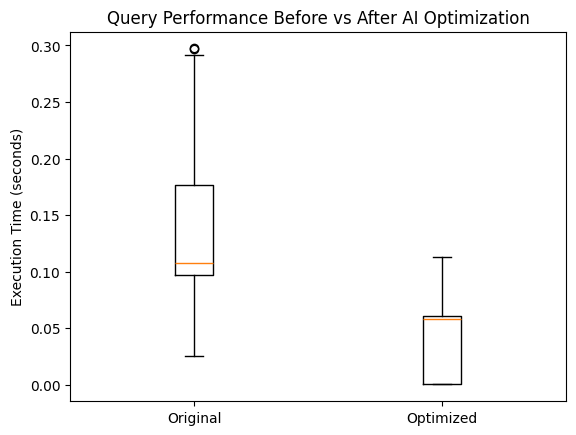

In [39]:
import matplotlib.pyplot as plt

plt.boxplot([
    ai_optimizer_df["original_time"],
    ai_optimizer_df["optimized_time"]
], labels=["Original", "Optimized"])

plt.title("Query Performance Before vs After AI Optimization")
plt.ylabel("Execution Time (seconds)")
plt.show()


Improvement distribution:

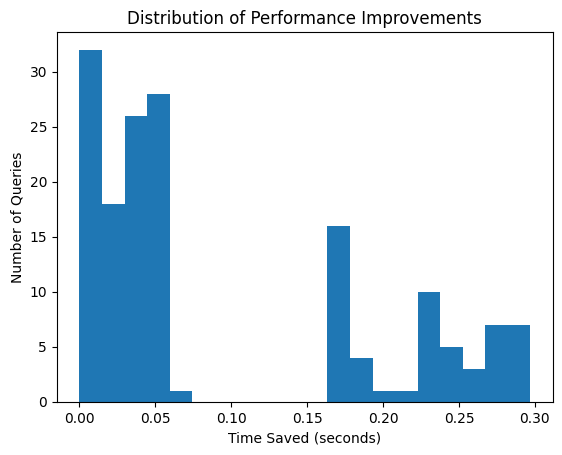

In [40]:
plt.hist(ai_optimizer_df["improvement"], bins=20)
plt.title("Distribution of Performance Improvements")
plt.xlabel("Time Saved (seconds)")
plt.ylabel("Number of Queries")
plt.show()


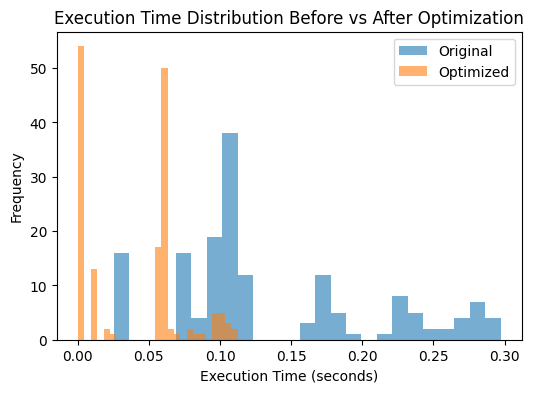

In [49]:
plt.figure(figsize=(6,4))
plt.hist(ai_optimizer_df["original_time"], bins=25, alpha=0.6, label="Original")
plt.hist(ai_optimizer_df["optimized_time"], bins=25, alpha=0.6, label="Optimized")
plt.legend()
plt.title("Execution Time Distribution Before vs After Optimization")
plt.xlabel("Execution Time (seconds)")
plt.ylabel("Frequency")
plt.show()

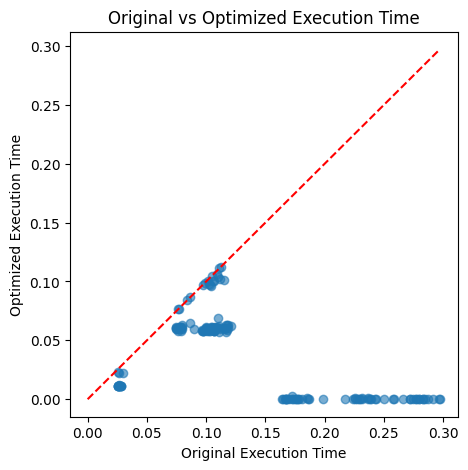

In [50]:
plt.figure(figsize=(5,5))
plt.scatter(ai_optimizer_df["original_time"],
            ai_optimizer_df["optimized_time"],
            alpha=0.6)

plt.plot([0, max(ai_optimizer_df["original_time"])],
         [0, max(ai_optimizer_df["original_time"])],
         'r--')

plt.xlabel("Original Execution Time")
plt.ylabel("Optimized Execution Time")
plt.title("Original vs Optimized Execution Time")
plt.show()

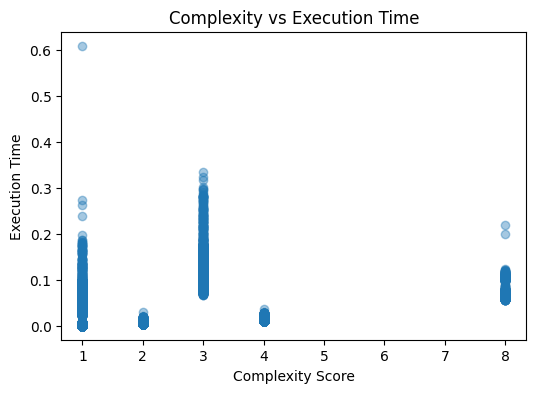

In [51]:
plt.figure(figsize=(6,4))
plt.scatter(df_real["complexity_score"],
            df_real["execution_time"],
            alpha=0.4)

plt.xlabel("Complexity Score")
plt.ylabel("Execution Time")
plt.title("Complexity vs Execution Time")
plt.show()

In [43]:
import numpy as np

print("========== PERFORMANCE METRICS ==========")

# Mean
mean_original = ai_optimizer_df['original_time'].mean()
mean_optimized = ai_optimizer_df['optimized_time'].mean()

# Median
median_original = ai_optimizer_df['original_time'].median()
median_optimized = ai_optimizer_df['optimized_time'].median()

# Standard deviation
std_original = ai_optimizer_df['original_time'].std()
std_optimized = ai_optimizer_df['optimized_time'].std()

# 95th percentile
p95_original = np.percentile(ai_optimizer_df['original_time'], 95)
p95_optimized = np.percentile(ai_optimizer_df['optimized_time'], 95)

# Percentage reductions
percent_reduction_mean = ((mean_original - mean_optimized) / mean_original) * 100
percent_reduction_median = ((median_original - median_optimized) / median_original) * 100
percent_reduction_p95 = ((p95_original - p95_optimized) / p95_original) * 100

print(f"Mean Execution Time (Before): {mean_original:.4f}")
print(f"Mean Execution Time (After): {mean_optimized:.4f}")
print(f"Mean Reduction (%): {percent_reduction_mean:.2f}%\n")

print(f"Median Execution Time (Before): {median_original:.4f}")
print(f"Median Execution Time (After): {median_optimized:.4f}")
print(f"Median Reduction (%): {percent_reduction_median:.2f}%\n")

print(f"95th Percentile (Before): {p95_original:.4f}")
print(f"95th Percentile (After): {p95_optimized:.4f}")
print(f"95th Percentile Reduction (%): {percent_reduction_p95:.2f}%\n")

print("========== VARIABILITY REDUCTION ==========")
variance_reduction = ((std_original - std_optimized) / std_original) * 100
print(f"Standard Deviation Reduction (%): {variance_reduction:.2f}%")

========== PERFORMANCE METRICS ==========
Mean Execution Time (Before): 0.1351
Mean Execution Time (After): 0.0396
Mean Reduction (%): 70.70%

Median Execution Time (Before): 0.1074
Median Execution Time (After): 0.0581
Median Reduction (%): 45.91%

95th Percentile (Before): 0.2797
95th Percentile (After): 0.1007
95th Percentile Reduction (%): 63.99%

========== VARIABILITY REDUCTION ==========
Standard Deviation Reduction (%): 52.90%


In [44]:
print("\n========== BUSINESS IMPACT MODEL ==========")

# Average time saved per query
ai_optimizer_df['time_saved'] = (
    ai_optimizer_df['original_time'] - ai_optimizer_df['optimized_time']
)

avg_time_saved = ai_optimizer_df['time_saved'].mean()
total_time_saved = ai_optimizer_df['time_saved'].sum()

print(f"Average Time Saved per Query (seconds): {avg_time_saved:.4f}")
print(f"Total Time Saved in Sample (seconds): {total_time_saved:.4f}")

# Assumptions for business projection
queries_per_day = 50000  # hypothetical workload scale
cost_per_cpu_hour = 3    # assumed cloud compute cost

daily_time_saved_sec = avg_time_saved * queries_per_day
daily_time_saved_hours = daily_time_saved_sec / 3600

daily_cost_saved = daily_time_saved_hours * cost_per_cpu_hour
annual_cost_saved = daily_cost_saved * 365

print(f"\nProjected Daily Time Saved (hours): {daily_time_saved_hours:.2f}")
print(f"Projected Daily Cost Saved ($): {daily_cost_saved:.2f}")
print(f"Projected Annual Cost Saved ($): {annual_cost_saved:.2f}")


========== BUSINESS IMPACT MODEL ==========
Average Time Saved per Query (seconds): 0.0955
Total Time Saved in Sample (seconds): 15.1877

Projected Daily Time Saved (hours): 1.33
Projected Daily Cost Saved ($): 3.98
Projected Annual Cost Saved ($): 1452.70


In [45]:
print("\n========== ROOT CAUSE ANALYSIS ==========")

root_cause_counts = anomalies['root_cause'].value_counts()
print(root_cause_counts)

root_cause_percent = (root_cause_counts / root_cause_counts.sum()) * 100
print("\nRoot Cause Percentage Distribution:")
print(root_cause_percent.round(2))


========== ROOT CAUSE ANALYSIS ==========
root_cause
Heavy scan with poor selectivity    89
General inefficiency                41
Full table scan                     29
Name: count, dtype: int64

Root Cause Percentage Distribution:
root_cause
Heavy scan with poor selectivity    55.97
General inefficiency                25.79
Full table scan                     18.24
Name: count, dtype: float64


In [48]:
total_queries = len(df_test)
total_anomalies = (anomalies['anomaly_flag'] == -1).sum()

anomaly_rate = (total_anomalies / total_queries) * 100

print(f"Total Queries: {total_queries}")
print(f"Anomalies Detected: {total_anomalies}")
print(f"Anomaly Rate (%): {anomaly_rate:.2f}%")

Total Queries: 3200
Anomalies Detected: 159
Anomaly Rate (%): 4.97%


Success rate:

In [41]:
(ai_optimizer_df["improvement"] > 0).mean()


np.float64(0.9433962264150944)

total seconds saved across workload:

In [42]:
total_time_saved = ai_optimizer_df["improvement"].sum()
total_time_saved


np.float64(15.187721014022827)

## Before optimization:
- 159 queries were detected by the model to be anomalous.
- the total wasted time by anomalous queries was calculated at 13.96 seconds
- the performance gap between normal & anomalous query were with the execution time window of (0.01 - 0.08) for normal and (0.1 - 0.18)

## After optimization:
- 159 queries were optimized by the Regular-expression based rewrite query generator.
- The total time saved by the optimization was 15.18 seconds
- The success rate of the optimization model was calculated at 94.33%
- the performance gap between normal & anomalous query was reduced with the execution time window of (0.1 - 0.18) for unoptimized to (0.01 - 0.06) for optimized closely matching the avg normal execution window as observed from the Box Plot.

## Exporting the data for Dashboard:

In [ ]:
print(anomalies.columns)
print(ai_optimizer_df.columns)


Index(['execution_time', 'rows_returned', 'join_count', 'aggregation',
       'filter_count', 'query_type', 'query_text', 'complexity_score',
       'scan_ratio', 'time_per_row', 'anomaly_flag', 'root_cause',
       'wasted_time'],
      dtype='object')
Index(['original_query', 'original_time', 'optimized_query', 'optimized_time',
       'improvement'],
      dtype='object')


In [ ]:
anomalies.to_csv("anomalies.csv", index=False)
ai_optimizer_df.to_csv("ai_optimizer_results.csv", index=False)


In [ ]:
df_real.to_csv("df_real.csv", index=False)
